# 02 — Feature Selection Comparison v2 (reference-aligned methods)

**Project:** AI-based Malicious URL Detection (Module: Sécurité des Données)
**Dataset:** ISCX-URL2016 pre-extracted numeric features (`All_clean.csv`)
**Goal:** replace the v1 ranking methods (PCA, LDA, Autoencoder) — which
assumed linear-variance or reconstruction structure — with four methods that
are **mathematically aligned** with the two reference subsets shipped with
the dataset:

| Method | Aligns with | Why it should overlap |
|---|---|---|
| Mutual Information (`mutual_info_classif`) | `All_Infogain.csv` | MI *is* Information Gain in the Weka `InfoGain Attribute Eval` sense |
| Random Forest with `criterion='entropy'` | `All_Infogain.csv` | every RF split is chosen to maximise Information Gain |
| Recursive Feature Elimination (`RFE`) | `All_BestFirst.csv` | wrapper-style subset search like BestFirst |
| Sequential Forward Selection (`SFS`) | `All_BestFirst.csv` | greedy forward subset search — the exact family of BestFirst |

**What this notebook deliberately does NOT do**

- No classifier training for predictive scoring. All F1 / precision / recall
  numbers here are **set-overlap** metrics comparing the selected feature
  set to the reference feature set — they measure *agreement between
  rankings*, not predictive quality. Classifier training belongs in
  `03_Modelling.ipynb`.

**Outputs** (saved under `notebooks/outputs/feature_selection_v2/`):

- `feature_similarity_results_v2.csv` — master results table (method × K)
- `final_selected_features_v2.csv` — winning feature list
- `reference_feature_sets_v2.json` — BestFirst / Infogain / union / intersection
- `summary_v2.md` — human-readable recap
- Heatmaps and bar charts as PNGs

## Section 1 — Setup

Imports, reproducible seeds (numpy / random / python hash), plotting
defaults, and an output directory for all artifacts produced by this
notebook.

In [22]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import (
    mutual_info_classif,
    RFE,
    SequentialFeatureSelector,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


RANDOM_SEED = 42


def reset_seeds(seed: int) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)


reset_seeds(RANDOM_SEED)


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.dpi'] = 120
warnings.filterwarnings('ignore')


PROJECT_ROOT = Path('/kaggle/working')
DATA_DIR = Path('/kaggle/input/datasets/benhammadilokmane/url-dataset')

OUT_DIR = PROJECT_ROOT / 'checkpoints' / 'outputs' / 'feature_selection_v2'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR}')
print(f'Output dir:   {OUT_DIR}')
print(f'Random seed:  {RANDOM_SEED}')

Project root: /kaggle/working
Data dir:     /kaggle/input/datasets/benhammadilokmane/url-dataset
Output dir:   /kaggle/working/checkpoints/outputs/feature_selection_v2
Random seed:  42


## Section 2 — Load data and extract reference feature sets

The two pre-selected subsets are used **only for their column headers** —
those headers *are* the reference feature lists we compare against.

In [23]:
ALL_PATH = DATA_DIR / 'All_clean.csv'
BF_PATH  = DATA_DIR / 'All_BestFirst.csv'
IG_PATH  = DATA_DIR / 'All_Infogain.csv'

df_all = pd.read_csv(ALL_PATH, low_memory=False)

bf_headers = pd.read_csv(BF_PATH, nrows=0).columns.tolist()
ig_headers = pd.read_csv(IG_PATH, nrows=0).columns.tolist()

TARGET_COL = 'class'

y_raw = df_all[TARGET_COL].copy()
X_all = df_all.drop(columns=[TARGET_COL]).apply(pd.to_numeric, errors='coerce')

ref_bestfirst    = [c for c in bf_headers if c != TARGET_COL]
ref_infogain     = [c for c in ig_headers if c != TARGET_COL]
ref_union        = sorted(set(ref_bestfirst) | set(ref_infogain))
ref_intersection = sorted(set(ref_bestfirst) & set(ref_infogain))

ohe = OneHotEncoder(sparse_output=False, dtype=np.int8)
y_onehot = ohe.fit_transform(y_raw.values.reshape(-1, 1))
ohe_classes = ohe.categories_[0]

y_encoded = np.argmax(y_onehot, axis=1)
class_map = {cls: idx for idx, cls in enumerate(ohe_classes)}

print(f'All_clean.csv shape:     {df_all.shape}')
print(f'Feature matrix shape:    {X_all.shape}')
print(f'Target classes:          {sorted(y_raw.unique())}')
print(f'One-hot matrix shape:    {y_onehot.shape}')
print(f'One-hot columns:         {list(ohe_classes)}')
print(f'Class -> column index:   {class_map}')
print(f'ref_bestfirst ({len(ref_bestfirst):2d}): {ref_bestfirst}')
print(f'ref_infogain  ({len(ref_infogain):2d}): {ref_infogain}')

All_clean.csv shape:     (26953, 79)
Feature matrix shape:    (26953, 78)
Target classes:          ['Defacement', 'benign', 'malware', 'phishing', 'spam']
One-hot matrix shape:    (26953, 5)
One-hot columns:         ['Defacement', 'benign', 'malware', 'phishing', 'spam']
Class -> column index:   {'Defacement': 0, 'benign': 1, 'malware': 2, 'phishing': 3, 'spam': 4}
ref_bestfirst ( 8): ['domain_token_count', 'executable', 'NumberofDotsinURL', 'Arguments_LongestWordLength', 'NumberRate_Domain', 'NumberRate_FileName', 'NumberRate_AfterPath', 'Entropy_Domain']
ref_infogain  (12): ['avgpathtokenlen', 'pathurlRatio', 'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'argPathRatio', 'CharacterContinuityRate', 'NumberRate_URL', 'NumberRate_FileName', 'NumberRate_AfterPath', 'Entropy_Domain']


## Section 3 — Preprocessing policy

Same preprocessing is applied to every method so any difference in the
resulting top-K sets comes from the *method*, not from inconsistent data
handling.

1. **Drop zero-variance columns** — no information, and they break
   `StandardScaler` (division by zero std).
2. **Sentinel `-1` → `NaN`** — in the ISCX feature extractor `-1` means
   "field absent" (no extension / no query / etc.). Treating it as a real
   value would bias means and distort MI / RFE scores.
3. **Median imputation** — robust to the heavy tails of `ldl_*` / `dld_*`
   counters.
4. **StandardScaler** — needed for RFE's Logistic Regression estimator.

> Data-leakage disclaimer. We fit the imputer/scaler on the full dataset
> before ranking. For pure feature ranking this is fine; a real
> classification pipeline would fit them inside a cross-validation fold.

In [24]:
nunique = X_all.nunique(dropna=True)
constant_cols = nunique[nunique <= 1].index.tolist()
X = X_all.drop(columns=constant_cols).copy()
print(f'Dropped {len(constant_cols)} constant column(s): {constant_cols}')

n_minus_one = int((X == -1).sum().sum())
X = X.replace(-1, np.nan)
print(f'Replaced {n_minus_one:,} `-1` sentinels with NaN')

n_inf = int(np.isinf(X.values).sum())
X = X.replace([np.inf, -np.inf], np.nan)
print(f'Replaced {n_inf:,} infinite values with NaN')
print(f'Total NaN cells after cleaning: {int(X.isna().sum().sum()):,}')

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

feature_names = X.columns.tolist()
n_features = len(feature_names)
print(f'Preprocessed feature matrix X_scaled: {X_scaled.shape}')

Dropped 0 constant column(s): []
Replaced 202,818 `-1` sentinels with NaN
Replaced 10 infinite values with NaN
Total NaN cells after cleaning: 217,551
Preprocessed feature matrix X_scaled: (26953, 78)


## Section 4 — Method 1: Mutual Information (mimics InfoGain)

`sklearn.feature_selection.mutual_info_classif` estimates the mutual
information $I(X_j; Y)$ between each feature and the target. This is
mathematically equivalent to Weka's `InfoGainAttributeEval` — the same
objective that produced `All_Infogain.csv`. We therefore expect the top-K
MI ranking to **overlap strongly with `ref_infogain`**.

In [25]:
mi_scores = mutual_info_classif(
    X_scaled, y_encoded,
    discrete_features=False,
    random_state=RANDOM_SEED,
)
mi_ranking = (
    pd.Series(mi_scores, index=feature_names)
      .sort_values(ascending=False)
)

print('Top 15 features by Mutual Information:')
print(mi_ranking.head(15).round(4))

Top 15 features by Mutual Information:
Entropy_Domain             1.0147
CharacterContinuityRate    0.6421
argDomanRatio              0.6274
argPathRatio               0.6238
pathurlRatio               0.6185
ArgUrlRatio                0.5882
domainUrlRatio             0.5794
pathDomainRatio            0.5768
NumberRate_FileName        0.5309
Entropy_DirectoryName      0.5294
NumberRate_URL             0.5180
avgpathtokenlen            0.4787
NumberRate_Extension       0.4691
avgdomaintokenlen          0.4519
NumberRate_AfterPath       0.4167
dtype: float64


## Section 5 — Method 2: Random Forest with `criterion='entropy'`

Switching the split criterion from Gini (the v1 default) to entropy forces
every node split to be chosen so it maximises Information Gain. The
resulting `feature_importances_` are therefore an Information-Gain-weighted
ensemble score — conceptually close to what `All_Infogain.csv` was built
from. We record importances only; we do **not** evaluate the forest
predictively.

In [26]:
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf.fit(X_scaled, y_encoded)

rf_ranking = (
    pd.Series(rf.feature_importances_, index=feature_names)
      .sort_values(ascending=False)
)

print('Top 15 features by Random Forest (entropy) importance:')
print(rf_ranking.head(15).round(4))

Top 15 features by Random Forest (entropy) importance:
NumberofDotsinURL          0.0455
domain_token_count         0.0446
SymbolCount_Domain         0.0391
tld                        0.0318
ArgUrlRatio                0.0300
NumberRate_Extension       0.0265
argPathRatio               0.0257
domainlength               0.0256
argDomanRatio              0.0250
CharacterContinuityRate    0.0233
avgdomaintokenlen          0.0214
Entropy_Domain             0.0210
domainUrlRatio             0.0209
host_letter_count          0.0203
SymbolCount_Extension      0.0199
dtype: float64


## Section 6 — Method 3: Recursive Feature Elimination (RFE)

RFE is a wrapper-style subset search: it fits the base estimator, drops the
weakest feature, refits, and repeats until the target size is reached. That
search procedure is in the same family as Weka's `BestFirst` / wrapper
subset search that produced `All_BestFirst.csv`.

We use `LogisticRegression(max_iter=1000)` as the base estimator — fast,
scale-sensitive (so our `StandardScaler` matters), and multinomial-safe.
Because RFE commits to one target size per run, we fit it once per
`K ∈ [8, 12, 20, 30, 40]`.

In [27]:
K_VALUES = [8, 12, 20, 30, 40]

rfe_selections = {}
for K in K_VALUES:
    base = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    selector = RFE(estimator=base, n_features_to_select=K, step=1)
    selector.fit(X_scaled, y_encoded)
    chosen = [f for f, keep in zip(feature_names, selector.support_) if keep]
    rfe_selections[K] = chosen
    print(f'RFE K={K:>2}: {chosen}')

RFE K= 8: ['Querylength', 'ldl_url', 'ldl_getArg', 'pathLength', 'pathurlRatio', 'domainUrlRatio', 'LongestVariableValue', 'LongestPathTokenLength']
RFE K=12: ['Querylength', 'avgdomaintokenlen', 'ldl_url', 'ldl_getArg', 'pathLength', 'ArgLen', 'pathurlRatio', 'argDomanRatio', 'domainUrlRatio', 'LongestVariableValue', 'URL_Letter_Count', 'LongestPathTokenLength']
RFE K=20: ['Querylength', 'avgdomaintokenlen', 'longdomaintokenlen', 'tld', 'ldl_url', 'ldl_getArg', 'domainlength', 'pathLength', 'ArgLen', 'pathurlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'LongestVariableValue', 'Extension_DigitCount', 'URL_Letter_Count', 'host_letter_count', 'Query_LetterCount', 'LongestPathTokenLength', 'SymbolCount_Domain']
RFE K=30: ['Querylength', 'path_token_count', 'avgdomaintokenlen', 'longdomaintokenlen', 'tld', 'charcompvowels', 'ldl_url', 'ldl_getArg', 'urlLen', 'domainlength', 'pathLength', 'subDirLen', 'ArgLen', 'pathurlRatio', 'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio

## Section 7 — Method 4: Sequential Forward Selection (mimics BestFirst)

`SequentialFeatureSelector(direction='forward')` starts from the empty set
and greedily adds the feature that most improves cross-validated accuracy
of the base estimator, stopping at `n_features_to_select`. That is exactly
the forward-search strategy Weka's `BestFirst` uses, so SFS is our
**closest procedural match to `All_BestFirst.csv`**.

We use `DecisionTreeClassifier(max_depth=5)` as a fast, interaction-aware
base estimator (Logistic Regression would ignore non-linear feature
interactions that the BestFirst run was implicitly looking for).

In [32]:
sfs_selections = {}
for K in K_VALUES:
    base = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_SEED)
    selector = SequentialFeatureSelector(
        estimator=base,
        n_features_to_select=K,
        direction='forward',
        n_jobs=-1,
    )
    selector.fit(X_scaled, y_encoded)
    chosen = [f for f, keep in zip(feature_names, selector.get_support()) if keep]
    sfs_selections[K] = chosen
    print(f'SFS K={K:>2}: {chosen}')

SFS K= 8: ['domainlength', 'Query_DigitCount', 'Query_LetterCount', 'Domain_LongestWordLength', 'Arguments_LongestWordLength', 'spcharUrl', 'delimeter_Domain', 'NumberRate_Extension']
SFS K=12: ['ldl_domain', 'ldl_filename', 'domainlength', 'Query_DigitCount', 'Query_LetterCount', 'Domain_LongestWordLength', 'Arguments_LongestWordLength', 'spcharUrl', 'delimeter_Domain', 'NumberRate_Extension', 'Entropy_Extension', 'Entropy_Afterpath']
SFS K=20: ['ldl_domain', 'ldl_filename', 'dld_domain', 'dld_filename', 'dld_getArg', 'domainlength', 'this.fileExtLen', 'executable', 'isPortEighty', 'Query_DigitCount', 'Query_LetterCount', 'Domain_LongestWordLength', 'Arguments_LongestWordLength', 'URL_sensitiveWord', 'spcharUrl', 'delimeter_Domain', 'NumberRate_Extension', 'SymbolCount_FileName', 'Entropy_Extension', 'Entropy_Afterpath']
SFS K=30: ['ldl_domain', 'ldl_filename', 'ldl_getArg', 'dld_domain', 'dld_filename', 'dld_getArg', 'domainlength', 'this.fileExtLen', 'executable', 'isPortEighty', 'L

## Section 8 — Top-K extraction

MI and RF give us a *full ranking*, so we slice the top-K from each at
every K. RFE and SFS already produce exact K-sized sets, so we reuse the
per-K dictionaries built in Sections 6–7.

In [33]:
top_k_sets = {
    'MutualInfo':   {K: list(mi_ranking.head(K).index) for K in K_VALUES},
    'RF_Entropy':   {K: list(rf_ranking.head(K).index) for K in K_VALUES},
    'RFE_LogReg':   {K: rfe_selections[K] for K in K_VALUES},
    'SFS_Tree':     {K: sfs_selections[K] for K in K_VALUES},
}

for method, kd in top_k_sets.items():
    print(f'\n=== {method} ===')
    for K, feats in kd.items():
        print(f'  K={K:>2}: {feats}')


=== MutualInfo ===
  K= 8: ['Entropy_Domain', 'CharacterContinuityRate', 'argDomanRatio', 'argPathRatio', 'pathurlRatio', 'ArgUrlRatio', 'domainUrlRatio', 'pathDomainRatio']
  K=12: ['Entropy_Domain', 'CharacterContinuityRate', 'argDomanRatio', 'argPathRatio', 'pathurlRatio', 'ArgUrlRatio', 'domainUrlRatio', 'pathDomainRatio', 'NumberRate_FileName', 'Entropy_DirectoryName', 'NumberRate_URL', 'avgpathtokenlen']
  K=20: ['Entropy_Domain', 'CharacterContinuityRate', 'argDomanRatio', 'argPathRatio', 'pathurlRatio', 'ArgUrlRatio', 'domainUrlRatio', 'pathDomainRatio', 'NumberRate_FileName', 'Entropy_DirectoryName', 'NumberRate_URL', 'avgpathtokenlen', 'NumberRate_Extension', 'avgdomaintokenlen', 'NumberRate_AfterPath', 'LongestPathTokenLength', 'Entropy_Filename', 'NumberofDotsinURL', 'Entropy_Extension', 'LongestVariableValue']
  K=30: ['Entropy_Domain', 'CharacterContinuityRate', 'argDomanRatio', 'argPathRatio', 'pathurlRatio', 'ArgUrlRatio', 'domainUrlRatio', 'pathDomainRatio', 'NumberRa

## Section 9 — Similarity metrics vs reference sets

All metrics below are **set-overlap** metrics. They compare the method's
top-K selection to a reference feature list; they say nothing about
predictive power.

- `overlap     = |A ∩ B|`
- `jaccard     = |A ∩ B| / |A ∪ B|`
- `precision@K = |A ∩ B| / K`
- `recall@K    = |A ∩ B| / |B|`
- `f1@K        = 2·P·R / (P + R + 1e-9)` — the `1e-9` guards divide-by-zero

`avg_*` columns are the simple average of the BestFirst and Infogain numbers.

In [34]:
def set_metrics(candidate, reference):
    '''Set-based comparison metrics with divide-by-zero protection.'''
    A, B = set(candidate), set(reference)
    inter = len(A & B)
    union = len(A | B)
    K = max(len(A), 1)
    ref_size = max(len(B), 1)

    jaccard   = inter / union if union else 0.0
    precision = inter / K
    recall    = inter / ref_size
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    return {
        'overlap':        inter,
        'jaccard':        jaccard,
        'precision_at_k': precision,
        'recall_at_k':    recall,
        'f1_at_k':        f1,
    }


rows = []
for method, kd in top_k_sets.items():
    for K, feats in kd.items():
        bf = set_metrics(feats, ref_bestfirst)
        ig = set_metrics(feats, ref_infogain)
        rows.append({
            'method':              method,
            'K':                   K,
            'overlap_bf':          bf['overlap'],
            'jaccard_bf':          bf['jaccard'],
            'precision_bf':        bf['precision_at_k'],
            'recall_bf':           bf['recall_at_k'],
            'f1_bf':               bf['f1_at_k'],
            'overlap_ig':          ig['overlap'],
            'jaccard_ig':          ig['jaccard'],
            'precision_ig':        ig['precision_at_k'],
            'recall_ig':           ig['recall_at_k'],
            'f1_ig':               ig['f1_at_k'],
            'avg_jaccard':         (bf['jaccard']        + ig['jaccard'])        / 2,
            'avg_precision_at_k':  (bf['precision_at_k'] + ig['precision_at_k']) / 2,
            'avg_recall_at_k':     (bf['recall_at_k']    + ig['recall_at_k'])    / 2,
            'avg_f1_at_k':         (bf['f1_at_k']        + ig['f1_at_k'])        / 2,
        })

results_df = pd.DataFrame(rows)
print('Per (method, K) similarity vs reference sets:')
try:
    display(results_df.round(3))
except NameError:
    print(results_df.round(3).to_string(index=False))

Per (method, K) similarity vs reference sets:


,method,K,overlap_bf,jaccard_bf,precision_bf,recall_bf,f1_bf,overlap_ig,jaccard_ig,precision_ig,recall_ig,f1_ig,avg_jaccard,avg_precision_at_k,avg_recall_at_k,avg_f1_at_k
0,MutualInfo,8,1,0.067,0.125,0.125,0.125,8,0.667,1.000,0.667,0.800,0.367,0.562,0.396,0.462
1,MutualInfo,12,2,0.111,0.167,0.250,0.200,11,0.846,0.917,0.917,0.917,0.479,0.542,0.583,0.558
2,MutualInfo,20,4,0.167,0.200,0.500,0.286,12,0.600,0.600,1.000,0.750,0.383,0.400,0.750,0.518
3,MutualInfo,30,5,0.152,0.167,0.625,0.263,12,0.400,0.400,1.000,0.571,0.276,0.283,0.812,0.417
4,MutualInfo,40,6,0.143,0.150,0.750,0.250,12,0.300,0.300,1.000,0.462,0.221,0.225,0.875,0.356
5,RF_Entropy,8,2,0.143,0.250,0.250,0.250,2,0.111,0.250,0.167,0.200,0.127,0.250,0.208,0.225
6,RF_Entropy,12,3,0.176,0.250,0.375,0.300,5,0.263,0.417,0.417,0.417,0.220,0.333,0.396,0.358
7,RF_Entropy,20,3,0.120,0.150,0.375,0.214,8,0.333,0.400,0.667,0.500,0.227,0.275,0.521,0.357
8,RF_Entropy,30,4,0.118,0.133,0.500,0.211,10,0.312,0.333,0.833,0.476,0.215,0.233,0.667,0.343
9,RF_Entropy,40,5,0.116,0.125,0.625,0.208,11,0.268,0.275,0.917,0.423,0.192,0.200,0.771,0.316


## Section 10 — Final comparison and automated selection

Selection rule:

> **Maximise `avg_jaccard`. Tie-break on `avg_precision_at_k`.**

After applying the rule we also report, as a sanity check of our
hypothesis, the best MI-vs-Infogain match and the best SFS-vs-BestFirst
match. Those two pairs are the ones mathematically *designed* to align,
and if the alignment holds the winning row will usually come from them.

In [35]:
ordered = results_df.sort_values(
    by=['avg_jaccard', 'avg_precision_at_k'],
    ascending=[False, False],
).reset_index(drop=True)

best_row       = ordered.iloc[0]
chosen_method  = str(best_row['method'])
chosen_K       = int(best_row['K'])
final_features = list(top_k_sets[chosen_method][chosen_K])

final_set = set(final_features)
ov_bf     = sorted(final_set & set(ref_bestfirst))
ov_ig     = sorted(final_set & set(ref_infogain))

print('=' * 72)
print('AUTOMATED FINAL RECOMMENDATION')
print('=' * 72)
print(f'Chosen method:        {chosen_method}')
print(f'Chosen K:             {chosen_K}')
print(f'avg_jaccard:          {best_row["avg_jaccard"]:.4f}')
print(f'avg_precision@K:      {best_row["avg_precision_at_k"]:.4f}')
print(f'avg_recall@K:         {best_row["avg_recall_at_k"]:.4f}')
print(f'avg_f1@K:             {best_row["avg_f1_at_k"]:.4f}')
print(f'overlap w/ BestFirst: {len(ov_bf):2d} -> {ov_bf}')
print(f'overlap w/ Infogain:  {len(ov_ig):2d} -> {ov_ig}')
print(f'\nFinal selected features ({len(final_features)}):')
for f in final_features:
    print(f'  - {f}')

mi_vs_ig = (
    results_df.query("method == 'MutualInfo'")
              .sort_values('jaccard_ig', ascending=False)
              .iloc[0]
)
sfs_vs_bf = (
    results_df.query("method == 'SFS_Tree'")
              .sort_values('jaccard_bf', ascending=False)
              .iloc[0]
)

print('\n' + '-' * 72)
print('Hypothesis check — method ↔ reference alignment')
print('-' * 72)
print(f'Best MI vs Infogain:   K={int(mi_vs_ig["K"])}, '
      f'jaccard={mi_vs_ig["jaccard_ig"]:.3f}, overlap={int(mi_vs_ig["overlap_ig"])}/'
      f'{len(ref_infogain)}')
print(f'Best SFS vs BestFirst: K={int(sfs_vs_bf["K"])}, '
      f'jaccard={sfs_vs_bf["jaccard_bf"]:.3f}, overlap={int(sfs_vs_bf["overlap_bf"])}/'
      f'{len(ref_bestfirst)}')

AUTOMATED FINAL RECOMMENDATION
Chosen method:        MutualInfo
Chosen K:             12
avg_jaccard:          0.4786
avg_precision@K:      0.5417
avg_recall@K:         0.5833
avg_f1@K:             0.5583
overlap w/ BestFirst:  2 -> ['Entropy_Domain', 'NumberRate_FileName']
overlap w/ Infogain:  11 -> ['ArgUrlRatio', 'CharacterContinuityRate', 'Entropy_Domain', 'NumberRate_FileName', 'NumberRate_URL', 'argDomanRatio', 'argPathRatio', 'avgpathtokenlen', 'domainUrlRatio', 'pathDomainRatio', 'pathurlRatio']

Final selected features (12):
  - Entropy_Domain
  - CharacterContinuityRate
  - argDomanRatio
  - argPathRatio
  - pathurlRatio
  - ArgUrlRatio
  - domainUrlRatio
  - pathDomainRatio
  - NumberRate_FileName
  - Entropy_DirectoryName
  - NumberRate_URL
  - avgpathtokenlen

------------------------------------------------------------------------
Hypothesis check — method ↔ reference alignment
------------------------------------------------------------------------
Best MI vs Infogain: 

## Section 11 — Visualisations

Three plots, each saved to `OUT_DIR` via `plt.savefig` *before* `plt.show`
so artifacts exist even if the notebook is rendered non-interactively.

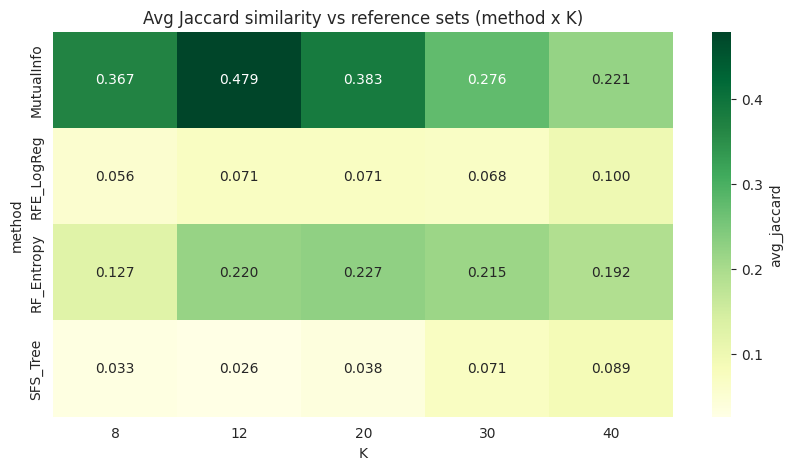

In [36]:
heat_jaccard = results_df.pivot(index='method', columns='K', values='avg_jaccard')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heat_jaccard, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
    cbar_kws={'label': 'avg_jaccard'},
)
ax.set_title('Avg Jaccard similarity vs reference sets (method x K)')
plt.savefig(OUT_DIR / 'heatmap_avg_jaccard.png')
plt.show()

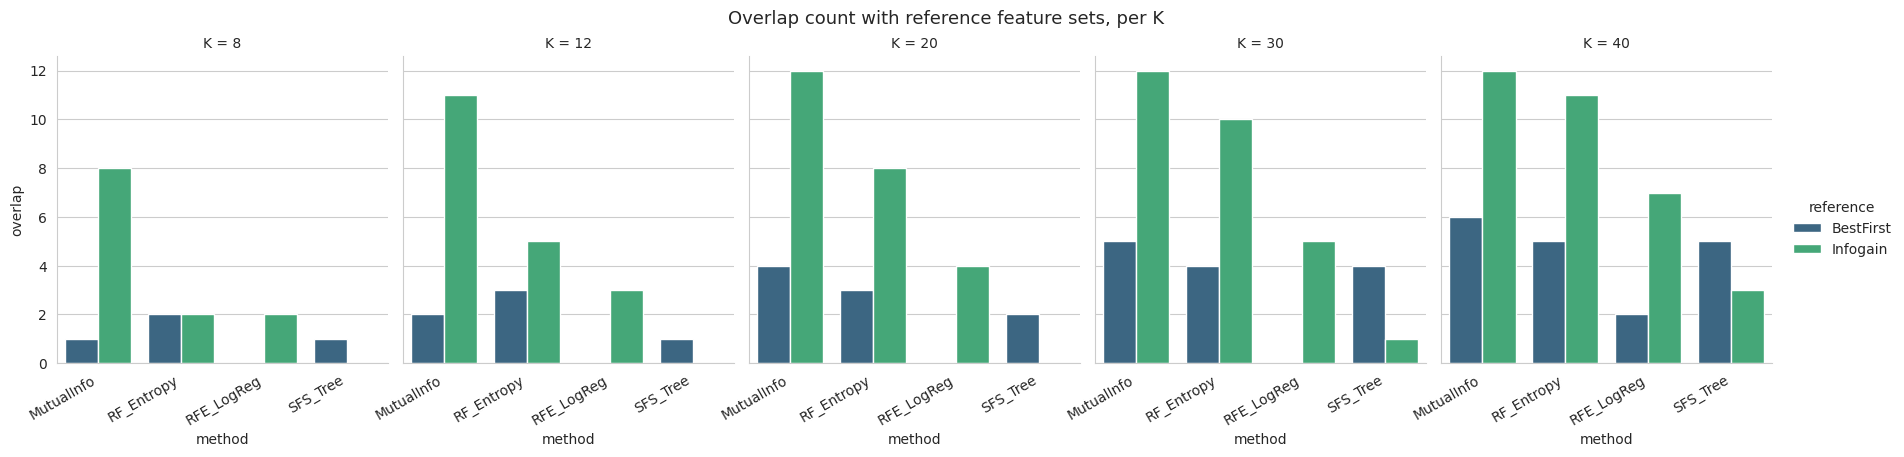

In [37]:
melted = results_df.melt(
    id_vars=['method', 'K'],
    value_vars=['overlap_bf', 'overlap_ig'],
    var_name='reference', value_name='overlap',
)
melted['reference'] = melted['reference'].map({
    'overlap_bf': 'BestFirst',
    'overlap_ig': 'Infogain',
})

g = sns.catplot(
    data=melted, x='method', y='overlap', hue='reference',
    col='K', kind='bar', palette='viridis',
    height=4, aspect=0.9, sharey=True,
)
g.set_xticklabels(rotation=30, ha='right')
g.fig.suptitle('Overlap count with reference feature sets, per K', y=1.03,
               fontsize=13)
plt.savefig(OUT_DIR / 'overlap_grouped_bars.png')
plt.show()

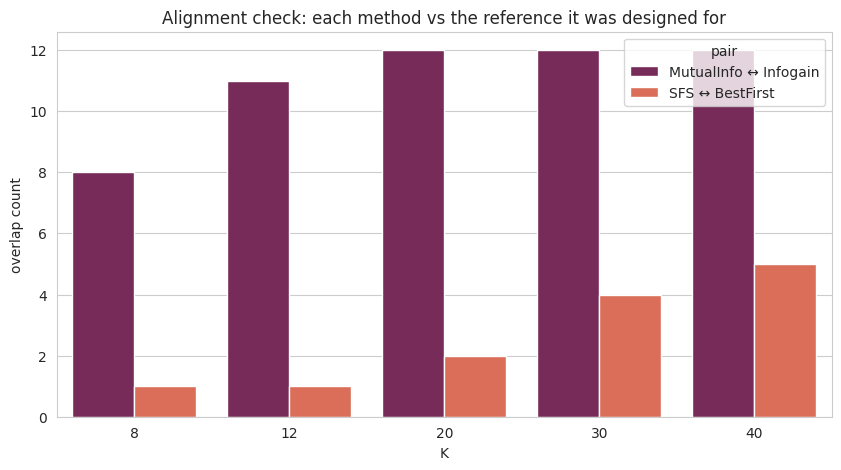

In [38]:
focus = pd.concat([
    results_df.query("method == 'MutualInfo'")[['K', 'overlap_ig']]
              .assign(pair='MutualInfo ↔ Infogain')
              .rename(columns={'overlap_ig': 'overlap'}),
    results_df.query("method == 'SFS_Tree'")[['K', 'overlap_bf']]
              .assign(pair='SFS ↔ BestFirst')
              .rename(columns={'overlap_bf': 'overlap'}),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=focus, x='K', y='overlap', hue='pair', palette='rocket', ax=ax)
ax.set_title('Alignment check: each method vs the reference it was designed for')
ax.set_ylabel('overlap count')
plt.savefig(OUT_DIR / 'alignment_check.png')
plt.show()

## Section 12 — Export artifacts

All output files are written under
`notebooks/outputs/feature_selection_v2/` (or its Kaggle equivalent) so
they can be committed alongside the notebook in the project report.

In [40]:
master_csv = OUT_DIR / 'feature_similarity_results_v2.csv'
results_df.to_csv(master_csv, index=False)

final_csv = OUT_DIR / 'final_selected_features_v2.csv'
pd.Series(final_features, name='feature').to_csv(final_csv, index=False)

ref_json = OUT_DIR / 'reference_feature_sets_v2.json'
with open(ref_json, 'w', encoding='utf-8') as f:
    json.dump({
        'ref_bestfirst':    ref_bestfirst,
        'ref_infogain':     ref_infogain,
        'ref_union':        ref_union,
        'ref_intersection': ref_intersection,
    }, f, indent=2)

summary_path = OUT_DIR / 'summary_v2.md'
summary_lines = [
    '# Feature Selection Comparison v2 — Final Summary',
    '',
    f'- **Chosen method:**       `{chosen_method}`',
    f'- **Chosen K:**            `{chosen_K}`',
    f'- **avg_jaccard:**         `{best_row["avg_jaccard"]:.4f}`',
    f'- **avg_precision@K:**     `{best_row["avg_precision_at_k"]:.4f}`',
    f'- **avg_recall@K:**        `{best_row["avg_recall_at_k"]:.4f}`',
    f'- **avg_f1@K:**            `{best_row["avg_f1_at_k"]:.4f}`',
    f'- **overlap with BestFirst ({len(ov_bf)}):** `{ov_bf}`',
    f'- **overlap with Infogain  ({len(ov_ig)}):** `{ov_ig}`',
    '',
    f'## Final selected features ({len(final_features)})',
    '',
]
summary_lines += [f'- `{f}`' for f in final_features]
summary_lines += [
    '',
    '## Reference sets',
    '',
    f'- BestFirst    ({len(ref_bestfirst)}): `{ref_bestfirst}`',
    f'- Infogain     ({len(ref_infogain)}): `{ref_infogain}`',
    f'- Union        ({len(ref_union)}): `{ref_union}`',
    f'- Intersection ({len(ref_intersection)}): `{ref_intersection}`',
]
summary_path.write_text('\n'.join(summary_lines), encoding='utf-8')

print(f'Wrote: {master_csv}')
print(f'Wrote: {final_csv}')
print(f'Wrote: {ref_json}')
print(f'Wrote: {summary_path}')
print()
print('All artifacts saved under:', OUT_DIR)

Wrote: /kaggle/working/checkpoints/outputs/feature_selection_v2/feature_similarity_results_v2.csv
Wrote: /kaggle/working/checkpoints/outputs/feature_selection_v2/final_selected_features_v2.csv
Wrote: /kaggle/working/checkpoints/outputs/feature_selection_v2/reference_feature_sets_v2.json
Wrote: /kaggle/working/checkpoints/outputs/feature_selection_v2/summary_v2.md

All artifacts saved under: /kaggle/working/checkpoints/outputs/feature_selection_v2
